In [17]:
from RRAM import Montecarlo as mc

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [18]:
# comienzo leyendo los datos de la simulación almacenados en un archivo csv dentro de la carpeta Init y los guardo en sus respectivas variables
sim_parmtrs = mc.read_csv_to_dic("Init_data/simulation_parameters.csv")
sim_ctes = mc.read_csv_to_dic("Init_data/simulation_constants.csv")

# Defino la carpeta donde se guardan los datos iniciales de la simulación
carpeta = 'Results'

In [19]:
def Plot_2panel(data_path: str, title: str = None) -> None:
    """
    Función que representa los datos obtenidos de la simulación en un panel con 2 subplots.
    Los subplots están dispuestos en una columna (uno sobre el otro).

    Args:
    data_path: Ruta del archivo CSV con los datos. La primera columna contiene la variable independiente y las siguientes columnas las variables dependientes.
    title: Título opcional para la figura.

    Returns:
        None
    """

    # Leo los datos desde el CSV
    data = pd.read_csv(data_path)

    # Extraigo la variable independiente y las dos primeras variables dependientes
    x = data.iloc[:, 0]
    y = data.iloc[:, 1:5]  # Solo las dos primeras columnas dependientes

    # Creo la figura y los subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

    # Establezco el título del conjunto de figuras si se ha proporcionado uno
    if title is not None:
        fig.suptitle(title, fontsize=16)

    # Creo el primer subplot
    ax1.plot(x, y.iloc[:, 0])
    ax1.set_title('Velocidad')

    # añado una etiqueta al eje x
    ax1.set_xlabel('Tiempo [s]')
    ax1.set_ylabel('Velocidad [m/s]')

    # Creo el segundo subplot
    ax2.plot(x, y.iloc[:, 3])
    ax2.set_title('Probabilidad de recombinación')

    # añado una etiqueta al eje x
    ax2.set_xlabel('Tiempo [s]')
    ax2.set_ylabel('Probabilidad de recombinación')

    # Ajustamos el espacio entre los plots
    fig.tight_layout()

    # Ajusto el espacio para el título principal si se ha proporcionado uno
    if title is not None:
        fig.subplots_adjust(top=0.88)

    # Guardo la figura
    if title is not None:
        partes = title.split(',')
        filename = f"Results/Panel_{data_path.split('/')[-1].split('.')[0]}_{partes[0].split('=')[1].strip()}-{partes[1].split('=')[1].strip()}.png"
    else:
        filename = f"Results/Panel_{data_path.split('/')[-1].split('.')[0]}.png"

    plt.savefig(filename)

    # Cierro la figura
    plt.close(fig)

    return None

In [20]:
# Plot_2panel(f'Results/resultados_0.csv', title=fr'$\gamma^{{drift}} = 9$, $E_m = 0.9$ eV ')

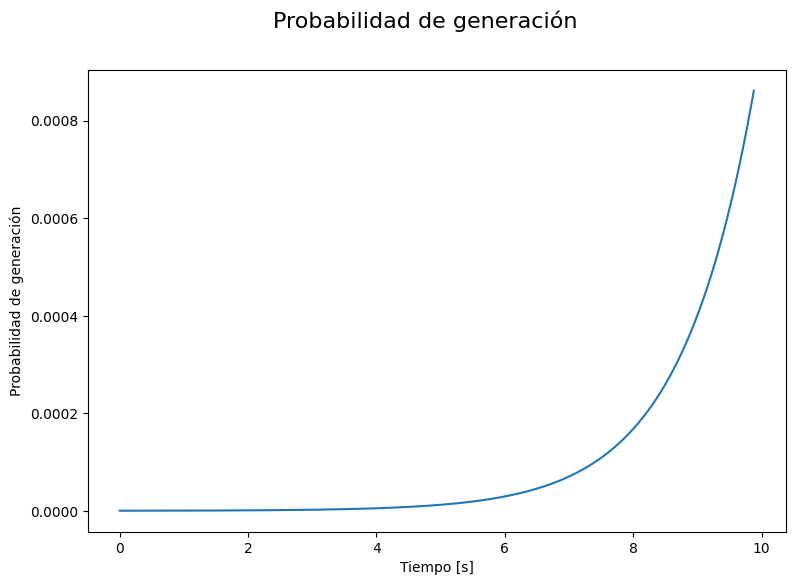

In [21]:
# Leo los datos desde el CSV
data = pd.read_csv('Results/resultados_0.csv')

# Extraigo la variable independiente y las dos primeras variables dependientes
x = data.iloc[:, 0]
y = data.iloc[:, 3]  # Solo las dos primeras columnas dependientes

# Creo la figura y los subplots
fig, ax1 = plt.subplots(figsize=(9, 6))

# Establezco el título del conjunto de figuras si se ha proporcionado uno
fig.suptitle('Probabilidad de generación', fontsize=16)

# Creo el primer subplot
ax1.plot(x, y)

# añado una etiqueta al eje x
ax1.set_xlabel('Tiempo [s]')
ax1.set_ylabel('Probabilidad de generación')

plt.savefig('Results/Prob_generacion.png')